In [3]:
import seaborn as sns
import pandas as pd
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.patheffects as path_effects  # Import path effects for text outline
plt.rcParams["font.family"] = "Nimbus sans" #"Helvetica"
custom_cmap = LinearSegmentedColormap.from_list("piyg", list(reversed(['#1a9641','#d02c91', '#f1b6da'])))

# Load in cellulo data

In [3]:
fns

[]

In [4]:
# Define the base directory
base_dir = '/Volumes/OPERA3/Nathan/data/macrohet/incellulo_timer_flow/data' #/mnt/OPERA3/Nathan/data/phthimer/ptimer_dt_manuscript/p_timer_data'# '/mnt/SYNO/macrohet_syno/data/ptimer/p_timer_data/'
# List all CSV files excluding 'in vitro' and 'invitro' files
fns = [
    fn for fn in os.listdir(base_dir) 
    if fn.endswith('.csv') 
    and 'in vitro' not in fn 
    and 'invitro' not in fn
    and 'Clean2' in fn
]

# Generate full file paths
file_paths = [os.path.join(base_dir, fn) for fn in fns]

# Function to extract compound name from filename
def extract_compound(file_name):
    compounds = ["control", "PZA", "INH", "RIF"]
    for compound in compounds:
        if compound in file_name:
            return compound
    return "Unknown"

# Load and concatenate all CSVs with compound labels
df_list = []
for file in file_paths:
    df = pd.read_csv(file)
    df["Compound"] = extract_compound(os.path.basename(file))  # Add compound label
    df_list.append(df)

# Concatenate all DataFrames
in_cellulo_df = pd.concat(df_list, ignore_index=True)
# rename control for aesthetic purposes, to match rest of paper
in_cellulo_df['Compound'] = in_cellulo_df['Compound'].replace({'control': 'CTRL'})  
in_cellulo_df['Ratio'] = in_cellulo_df['530_30-Blue-A']/in_cellulo_df['582_15-Yellow-A']
in_cellulo_df

,FSC-A,FSC-H,SSC-A,SSC-H,530_30-Blue-A,582_15-Yellow-A,Time,Compound,Ratio
0,59,36,25,18,352,232,0,INH,1.517241
1,113,75,90,74,504,532,0,INH,0.947368
2,56,47,75,70,609,658,0,INH,0.925532
3,284,229,231,187,434,167,0,INH,2.598802
4,48,48,42,45,518,514,0,INH,1.007782
...,...,...,...,...,...,...,...,...,...
42490,30,25,44,38,447,286,1023,CTRL,1.562937
42491,295,206,491,405,548,429,1023,CTRL,1.277389
42492,182,159,138,131,577,450,1023,CTRL,1.282222
42493,85,72,126,111,581,503,1023,CTRL,1.155070


In [5]:
in_cellulo_df.to_parquet('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/flow_data.parquet')

In [5]:
in_cellulo_df = pd.read_parquet('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/flow_data.parquet')

In [6]:
in_cellulo_df

,FSC-A,FSC-H,SSC-A,SSC-H,530_30-Blue-A,582_15-Yellow-A,Time,Compound,Ratio
0,59,36,25,18,352,232,0,INH,1.517241
1,113,75,90,74,504,532,0,INH,0.947368
2,56,47,75,70,609,658,0,INH,0.925532
3,284,229,231,187,434,167,0,INH,2.598802
4,48,48,42,45,518,514,0,INH,1.007782
...,...,...,...,...,...,...,...,...,...
42490,30,25,44,38,447,286,1023,CTRL,1.562937
42491,295,206,491,405,548,429,1023,CTRL,1.277389
42492,182,159,138,131,577,450,1023,CTRL,1.282222
42493,85,72,126,111,581,503,1023,CTRL,1.155070


# Revisions

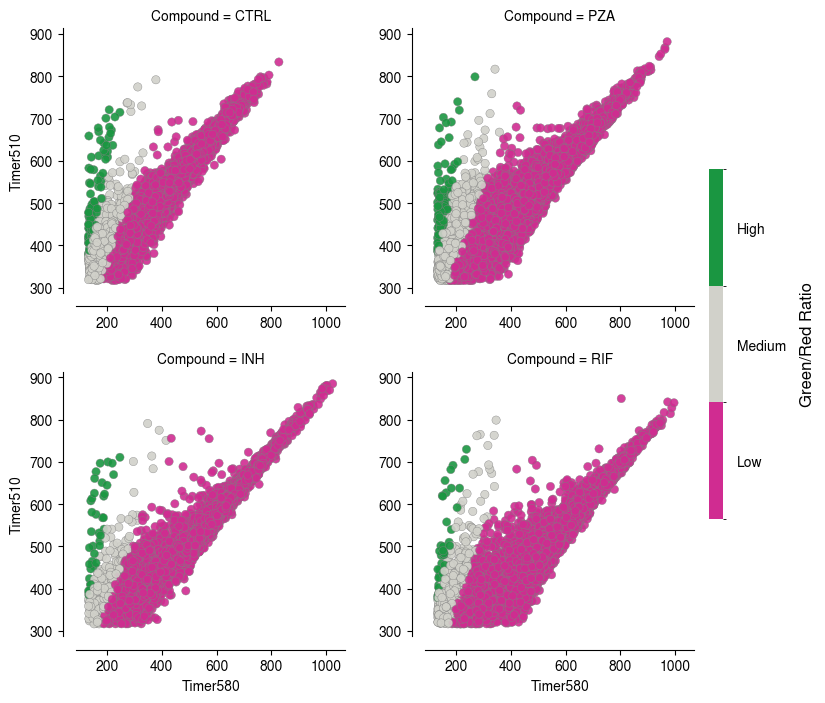

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define colors: Magenta (Low), Grey (Mid), Green (High)
colors = list(reversed(['#1a9641', '#d1d1ca', '#d02c91']))
cmap_3tone = ListedColormap(colors)

compound_order = ["CTRL", "PZA", "INH", "RIF"]

# Calculate range
vmin, vmax = in_cellulo_df["Ratio"].min(), in_cellulo_df["Ratio"].max()
r = vmax - vmin

# Shift bounds: 25% Magenta, 25% Grey, 50% Green
bounds = [vmin, vmin + 0.25 * r, vmin + 0.5 * r, vmax]
norm = BoundaryNorm(bounds, cmap_3tone.N)

g = sns.relplot(
    data=in_cellulo_df, 
    x='582_15-Yellow-A', 
    y='530_30-Blue-A', 
    palette=cmap_3tone,  
    hue_norm=norm, 
    col='Compound',
    col_order=compound_order,  
    col_wrap=2,  
    alpha=0.9,
    hue='Ratio',
    edgecolor='grey', 
    linewidth=0.3, 
    legend=False, 
    kind='scatter',
    height=3.5, 
    aspect=1,  
)

g.set_axis_labels("Timer580", "Timer510")
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)
sns.despine(offset=10)

# Create ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_3tone, norm=norm)
sm.set_array([]) 

cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5]) 

# Calculate ticks centered within the unequal bins
ticks = [
    vmin + 0.125 * r,   # Center of Magenta (0 to 0.25)
    vmin + 0.375 * r,   # Center of Grey (0.25 to 0.5)
    vmin + 0.75 * r     # Center of Green (0.5 to 1.0)
]

cbar = g.figure.colorbar(sm, cax=cbar_ax, ticks=ticks)
cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)
cbar.ax.set_yticklabels(['Low', 'Medium', 'High']) 

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=4, width=0., pad=6) 

plt.savefig('/mnt/OPERA3/Nathan/data/phthimer/ptimer_dt_manuscript/p_timer_results/gated_scatterplot.pdf', dpi=314, bbox_inches='tight')
plt.show()

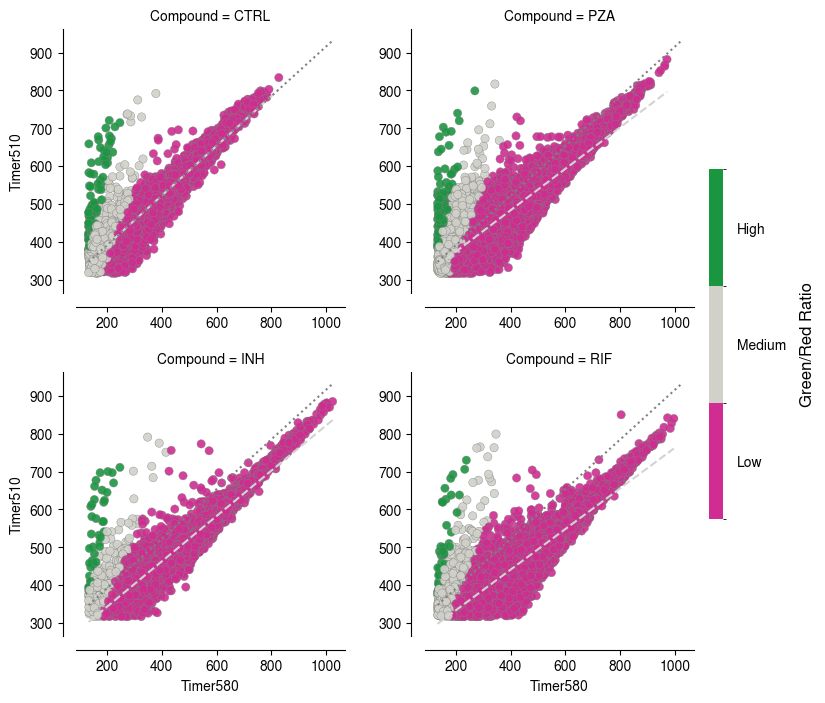

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define colors: Magenta (Low), Grey (Mid), Green (High)
colors = list(reversed(['#1a9641', '#d1d1ca', '#d02c91']))
cmap_3tone = ListedColormap(colors)

compound_order = ["CTRL", "PZA", "INH", "RIF"]

# Calculate range
vmin, vmax = in_cellulo_df["Ratio"].min(), in_cellulo_df["Ratio"].max()
r = vmax - vmin

# Shift bounds: 25% Magenta, 25% Grey, 50% Green
bounds = [vmin, vmin + 0.25 * r, vmin + 0.5 * r, vmax]
norm = BoundaryNorm(bounds, cmap_3tone.N)

# Calculate CTRL regression parameters (Global Reference)
ctrl_df = in_cellulo_df[in_cellulo_df['Compound'] == 'CTRL']
ctrl_slope, ctrl_intercept = np.polyfit(ctrl_df['582_15-Yellow-A'], ctrl_df['530_30-Blue-A'], 1)

g = sns.relplot(
    data=in_cellulo_df, 
    x='582_15-Yellow-A', 
    y='530_30-Blue-A', 
    palette=cmap_3tone,  
    hue_norm=norm, 
    col='Compound',
    col_order=compound_order,  
    col_wrap=2,  
    alpha=0.9,
    hue='Ratio',
    edgecolor='grey', 
    linewidth=0.3, 
    legend=False, 
    kind='scatter',
    height=3.5, 
    aspect=1,  
)

# 1. Add Local Line of Best Fit (Dashed Light Grey) to each subplot
g.map(sns.regplot, '582_15-Yellow-A', '530_30-Blue-A', scatter=False, ci=None, 
      line_kws={'linestyle': '--', 'color': 'lightgrey', 'linewidth': 1.5})

# 2. Add CTRL Reference Line (Dotted Dark Grey) to each subplot
x_vals = np.array([in_cellulo_df['582_15-Yellow-A'].min(), in_cellulo_df['582_15-Yellow-A'].max()])
y_vals = ctrl_slope * x_vals + ctrl_intercept

for ax in g.axes.flat:
    ax.plot(x_vals, y_vals, linestyle=':', color='grey', linewidth=1.5, label='CTRL Fit')

g.set_axis_labels("Timer580", "Timer510")
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)
sns.despine(offset=10)

# Colorbar setup
sm = plt.cm.ScalarMappable(cmap=cmap_3tone, norm=norm)
sm.set_array([]) 

cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5]) 

# Calculate ticks centered within the unequal bins
ticks = [
    vmin + 0.125 * r,   # Center of Magenta (0 to 0.25)
    vmin + 0.375 * r,   # Center of Grey (0.25 to 0.5)
    vmin + 0.75 * r     # Center of Green (0.5 to 1.0)
]

cbar = g.figure.colorbar(sm, cax=cbar_ax, ticks=ticks)
cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)
cbar.ax.set_yticklabels(['Low', 'Medium', 'High']) 

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=4, width=0., pad=6) 

plt.savefig('/mnt/OPERA3/Nathan/data/phthimer/ptimer_dt_manuscript/p_timer_results/gated_scatterplot.pdf', dpi=314, bbox_inches='tight')
plt.show()

## shift in gated populations

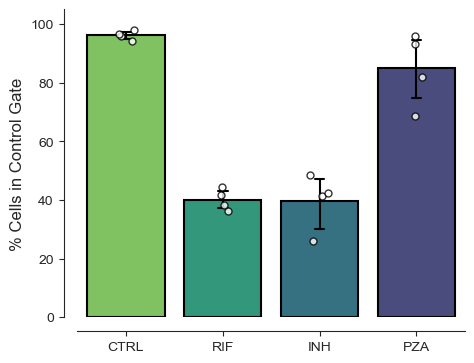

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reconstruct the data
data = {
    'CTRL': [96.0, 96.5, 97.9, 94.2],
    'RIF':  [41.7, 44.4, 36.3, 38.2],
    'INH':  [41.3, 48.6, 25.9, 42.3],
    'PZA':  [82.1, 93.1, 95.8, 68.5],
    # 'CHL':  [80.0, 70.6, 84.7, 59.8]
}

df_summary = pd.DataFrame(data)
df_melted = df_summary.melt(var_name='Compound', value_name='Percent_In_Gate')

# Capture explicit order
compound_order = list(data.keys()) 

plt.figure(figsize=(5, 4))
sns.set_style("ticks")

# 2. Create Barplot (Viridis Palette)
# We map hue to Compound to apply the palette across all 5 bars
ax = sns.barplot(
    data=df_melted,
    x='Compound',
    y='Percent_In_Gate',
    hue='Compound',       # Needed to apply palette to x-axis categories
    palette='viridis_r',    # Standard Python default map
    order=compound_order,
    edgecolor='black',    # Standard clean black edge
    linewidth=1.5,
    capsize=0.1,
    err_kws={'linewidth': 1.5, 'color': 'black'},
    dodge=False           # Centers bars
)

# 3. Overlay Stripplot
sns.stripplot(
    data=df_melted,
    x='Compound',
    y='Percent_In_Gate',
    order=compound_order,
    color='white',        # White dots stand out well against dark viridis bars
    edgecolor='black',
    linewidth=1,
    alpha=0.8,
    size=5,
    jitter=True,
    ax=ax
)

# Formatting
ax.set_ylabel("% Cells in Control Gate", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 105) 

sns.despine(offset=10)

plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/incellulo_timer_flow/results/gate_percentage_viridis.pdf', dpi=314, bbox_inches='tight')
plt.show()

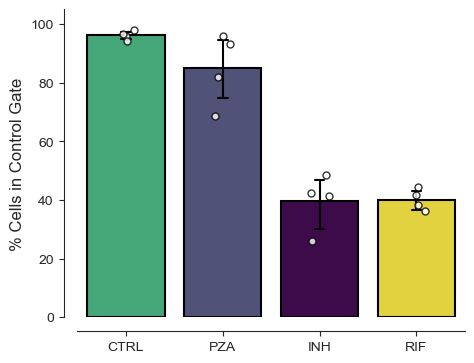

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reconstruct the data
data = {
    'CTRL': [96.0, 96.5, 97.9, 94.2],
    'PZA':  [82.1, 93.1, 95.8, 68.5],
    'INH':  [41.3, 48.6, 25.9, 42.3],
    'RIF':  [41.7, 44.4, 36.3, 38.2],
    
}

df_summary = pd.DataFrame(data)
df_melted = df_summary.melt(var_name='Compound', value_name='Percent_In_Gate')
compound_order = list(data.keys())

plt.figure(figsize=(5, 4))
sns.set_style("ticks")

# 2. Define Custom Palette
# Locking CTRL to Green and PZA to Blue. 
# Assigning RIF (Yellow) and INH (Dark Purple) for maximum contrast.
custom_palette = {
    'CTRL': '#35b779',  # Fixed: Viridis Green
    'PZA':  '#4a4c7e',   # Fixed: Viridis Blue/Teal
    'RIF':  '#fde725',  # Changed: Bright Yellow (Distinct from Green)
    'INH':  '#440154',  # Changed: Dark Purple (Distinct from Blue)
}

# 3. Create Barplot
ax = sns.barplot(
    data=df_melted,
    x='Compound',
    y='Percent_In_Gate',
    hue='Compound',
    palette=custom_palette,
    order=compound_order,
    edgecolor='black',
    linewidth=1.5,
    capsize=0.1,
    err_kws={'linewidth': 1.5, 'color': 'black'},
    dodge=False
)

# 4. Overlay Stripplot
sns.stripplot(
    data=df_melted,
    x='Compound',
    y='Percent_In_Gate',
    order=compound_order,
    color='white',
    edgecolor='black',
    linewidth=1,
    alpha=0.8,
    size=5,
    jitter=True,
    ax=ax
)

# Formatting
ax.set_ylabel("% Cells in Control Gate", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 105)

sns.despine(offset=10)

output_path = '/Volumes/OPERA3/Nathan/data/macrohet/incellulo_timer_flow/results/gate_percentage_viridis_distinct.pdf'
plt.savefig(output_path, dpi=314, bbox_inches='tight')
plt.show()

# Plot

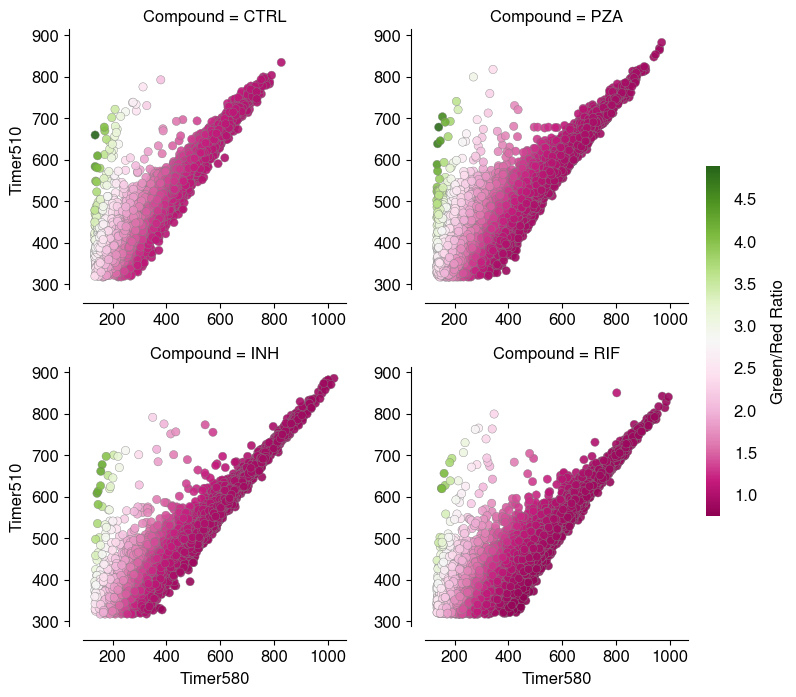

In [109]:
# Define compounds and colors
compound_order = ["CTRL", "PZA", "INH", "RIF"]

# Create scatterplot with subtle grey outlines
g = sns.relplot(
    data=in_cellulo_df, 
    x='582_15-Yellow-A', 
    y='530_30-Blue-A', 
    palette='PiYG',  
    col='Compound',
    col_order=compound_order,  
    col_wrap=2,  
    alpha=0.9,
    hue='Ratio',
    edgecolor='grey',  # Subtle grey outline
    linewidth=0.3,  # Thin outline for clarity
    legend=False,  # Disable default legend
    kind='scatter',
    height=3.5,  # Adjust subplot height (reduce for smaller plots)
    aspect=1,  
)

# Set axis labels and adjust layout
g.set_axis_labels("Timer580", "Timer510")
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)
sns.despine(offset=10)

# Add a colorbar manually **without squashing**
norm = mpl.colors.Normalize(vmin=in_cellulo_df["Ratio"].min(), vmax=in_cellulo_df["Ratio"].max())
sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
sm.set_array([])  # Dummy array for colorbar

# Create a new axis for the colorbar outside the plot
cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
cbar = g.figure.colorbar(sm, cax=cbar_ax)
cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)

# **Remove colorbar outline (spines)**
cbar.outline.set_visible(False)

# **Increase padding of tick labels**
cbar.ax.tick_params(length=4, width=0., pad=6)  # Adjust tick length, width, and padding

# Save the figure
plt.savefig('/mnt/OPERA3/Nathan/data/phthimer/ptimer_dt_manuscript/p_timer_results', dpi=314, bbox_inches='tight')
plt.show()

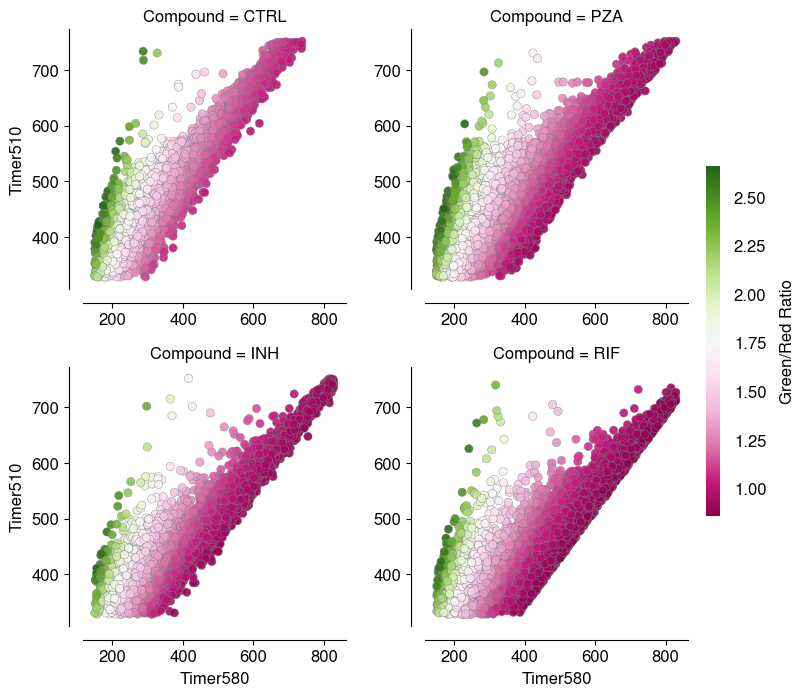

In [108]:
# Define compounds and colors
compound_order = ["CTRL", "PZA", "INH", "RIF"]


# Calculate bounds for Ratio, 530_30-Blue-A, and 582_15-Yellow-A
ratio_lower_bound = in_cellulo_df['Ratio'].quantile(lower_quantile)
ratio_upper_bound = in_cellulo_df['Ratio'].quantile(upper_quantile)

blue_lower_bound = in_cellulo_df['530_30-Blue-A'].quantile(lower_quantile)
blue_upper_bound = in_cellulo_df['530_30-Blue-A'].quantile(upper_quantile)

yellow_lower_bound = in_cellulo_df['582_15-Yellow-A'].quantile(lower_quantile)
yellow_upper_bound = in_cellulo_df['582_15-Yellow-A'].quantile(upper_quantile)

# Filter the DataFrame based on the bounds
subset_df = in_cellulo_df[
    (in_cellulo_df['Ratio'] >= ratio_lower_bound) &
    (in_cellulo_df['Ratio'] <= ratio_upper_bound) &
    (in_cellulo_df['530_30-Blue-A'] >= blue_lower_bound) &
    (in_cellulo_df['530_30-Blue-A'] <= blue_upper_bound) &
    (in_cellulo_df['582_15-Yellow-A'] >= yellow_lower_bound) &
    (in_cellulo_df['582_15-Yellow-A'] <= yellow_upper_bound)
]


# Create scatterplot with subtle grey outlines
g = sns.relplot(
    data=subset_df, 
    x='582_15-Yellow-A', 
    y='530_30-Blue-A', 
    palette='PiYG',  
    col='Compound',
    col_order=compound_order,  
    col_wrap=2,  
    alpha=0.9,
    hue='Ratio',
    edgecolor='grey',  # Subtle grey outline
    linewidth=0.3,  # Thin outline for clarity
    legend=False,  # Disable default legend
    kind='scatter',
    height=3.5,  # Adjust subplot height (reduce for smaller plots)
    aspect=1,  
)

# Set axis labels and adjust layout
g.set_axis_labels("Timer580", "Timer510")
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)
sns.despine(offset=10)

# Add a colorbar manually **without squashing**
norm = mpl.colors.Normalize(vmin=subset_df["Ratio"].min(), vmax=subset_df["Ratio"].max())
sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
sm.set_array([])  # Dummy array for colorbar

# Create a new axis for the colorbar outside the plot
cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
cbar = g.figure.colorbar(sm, cax=cbar_ax)
cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)

# **Remove colorbar outline (spines)**
cbar.outline.set_visible(False)

# **Increase padding of tick labels**
cbar.ax.tick_params(length=4, width=0., pad=6)  # Adjust tick length, width, and padding

# Save the figure
plt.savefig('/mnt/SYNO/macrohet_syno/data/ptimer/p_timer_results/in_cellulo/scatterplot_filtered.pdf', dpi=314, bbox_inches='tight')
plt.show()

# Histogram plots

In [ ]:
# needs to be 50x100mm 

In [6]:
# Define PiYG color palette
pal = sns.color_palette("PiYG", 4)[::-1]  # Generates 4 colors for each compound


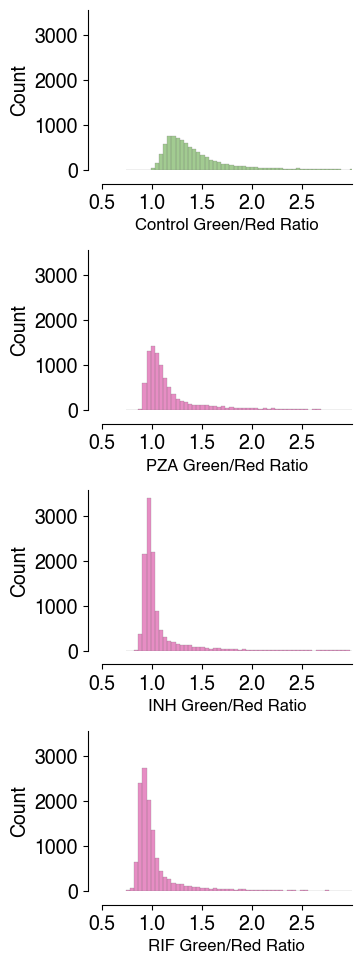

In [133]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Define a new column that distinguishes CTRL vs. Drug
in_cellulo_df['Condition'] = np.where(in_cellulo_df['Compound'] == "CTRL", "CTRL", "Drug")

# Define a custom palette with two colors
condition_palette = {
    "CTRL": '#479925',  # Green for CTRL
    "Drug": '#d01c8b'   # Magenta for Drug
}
# Set global font size
plt.rcParams.update({
    'font.size': 14,  # Increases base font size
    'axes.labelsize': 14,  # Increases axis label size
    'axes.titlesize': 14,  # Increases title size
    'xtick.labelsize': 14,  # Increases x-axis tick label size
    'ytick.labelsize': 14   # Increases y-axis tick label size
})

# Create the displot with hue based on Condition
g = sns.displot(data=in_cellulo_df, 
                x='Ratio', 
                col='Compound', 
                col_order=["CTRL", "PZA", "INH", "RIF"],  
                col_wrap=1,  # Single column layout
                bins=100,  
                kde=False,
                line_kws={"color": "lightgray", "linewidth": 2},  # Light gray KDE line
                facet_kws={'sharex': True, 'sharey': True},  
                aspect=1.5, 
                height=2.5,  
                hue='Condition',  # Now using Condition for hue
                palette=condition_palette,  # Custom palette with CTRL & Drug colors
                edgecolor='gray'
               )

# Add manual text labels below each subplot
for ax, compound_name in zip(g.axes.flatten(), g.col_names):
    if compound_name == 'CTRL':
        compound_name = 'Control'
    ax.text(0.5, -0.3, f"{compound_name} Green/Red Ratio", 
            fontsize=12, ha='center', va='top', transform=ax.transAxes)
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_xlim(0.5,3)
    # Set x-axis ticks at 0.5 intervals
    ax.set_xticks(np.arange(0.5, 3, 0.5))
# Adjust spacing to avoid overlapping
g.figure.subplots_adjust(hspace=0.5)

# Remove legend
if g._legend:  
    g._legend.remove()

# Remove spines for a cleaner look
sns.despine(offset=10)
# Save and show the figure
plt.savefig('/mnt/SYNO/macrohet_syno/data/ptimer/p_timer_results/histogram_1col.pdf', dpi=314, bbox_inches='tight')
plt.show()

# Repeat over in vitro repeats

In [4]:
# Define directories
base_dir = 'p_timer_data/'#test_subset'
save_dir = '/Volumes/OPERA3/Nathan/data/macrohet/incellulo_timer_flow/'  # Subdirectory for saving in vitro results
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

file_paths = [
                os.path.join(base_dir, fn) for fn in os.listdir(base_dir) 
                if fn.endswith('.csv') 
                and 'in vitro' in fn 
                or 'invitro' in fn
                # and 'Clean2' in fn
]

# Function to extract compound name from filename
def extract_compound(file_name):
    compounds = ["control", "CHL", "PZA", "INH", "RIF"]
    for compound in compounds:
        if compound in file_name:
            return compound
    return "Unknown"

# Load and concatenate all in vitro CSVs with compound labels
df_list = []
for file in file_paths:
    df = pd.read_csv(file)
    df["Compound"] = extract_compound(os.path.basename(file))  # Add compound label
    df_list.append(df)

# Concatenate all DataFrames
in_vitro_df = pd.concat(df_list, ignore_index=True)

# Rename control for aesthetic purposes
in_vitro_df['Compound'] = in_vitro_df['Compound'].replace({'control': 'CTRL'})  

# Replace zero values with NaN in the relevant columns
in_vitro_df['530_30-Blue-A'] = in_vitro_df['530_30-Blue-A'].replace(0, np.nan)
in_vitro_df['582_15-Yellow-A'] = in_vitro_df['582_15-Yellow-A'].replace(0, np.nan)
in_vitro_df['530_30-Blue-A'] = in_vitro_df['530_30-Blue-A'].replace(1023, np.nan)
in_vitro_df['582_15-Yellow-A'] = in_vitro_df['582_15-Yellow-A'].replace(1023, np.nan)

# Drop rows where either column has NaN values
in_vitro_df = in_vitro_df.dropna(subset=['530_30-Blue-A', '582_15-Yellow-A'])

# Calculate the ratio
in_vitro_df['Ratio'] = in_vitro_df['530_30-Blue-A'] / in_vitro_df['582_15-Yellow-A']


In [5]:
in_vitro_df

,FSC-A,FSC-H,SSC-A,SSC-H,530_30-Blue-A,582_15-Yellow-A,Time,Compound,Ratio
4,667,597,196,165,632.0,740.0,1,INH,0.854054
6,266,268,139,90,598.0,727.0,1,INH,0.822558
7,23,59,150,147,537.0,618.0,1,INH,0.868932
8,89,160,146,104,529.0,637.0,1,INH,0.830455
9,36,68,141,94,528.0,630.0,1,INH,0.838095
...,...,...,...,...,...,...,...,...,...
353543,20,22,17,34,310.0,426.0,1023,CHL,0.727700
353544,44,39,60,55,585.0,679.0,1023,CHL,0.861561
353545,32,31,27,33,484.0,570.0,1023,CHL,0.849123
353546,36,29,31,26,507.0,592.0,1023,CHL,0.856419


In [60]:
in_vitro_df['530_30-Blue-A'].max()

1023.0

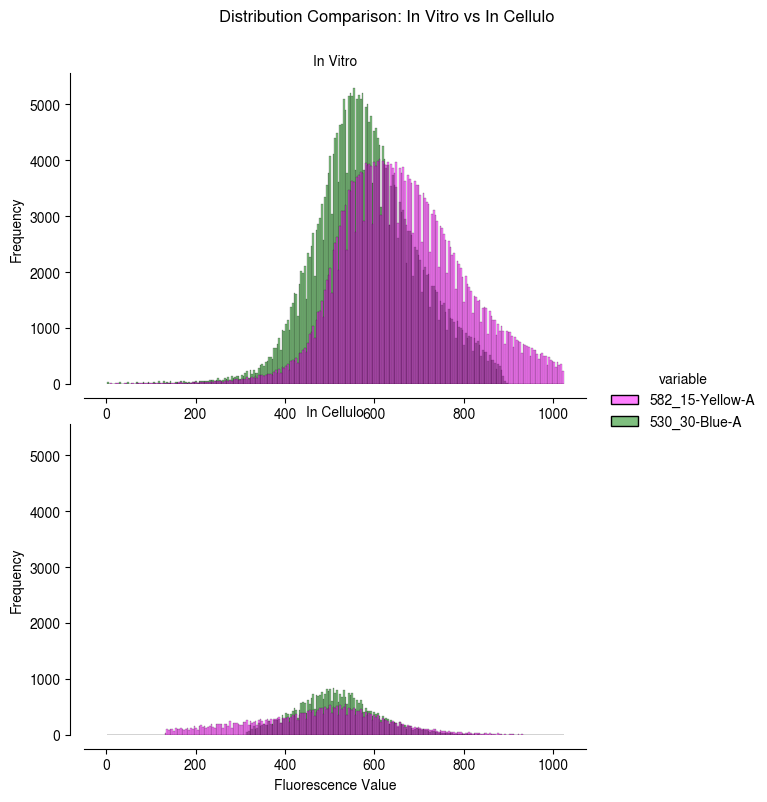

In [67]:
# Create a combined DataFrame for easier plotting
in_vitro_df['Dataset'] = 'In Vitro'
in_cellulo_df['Dataset'] = 'In Cellulo'
combined_df = pd.concat([in_vitro_df, in_cellulo_df])

# Melt the DataFrame for easier plotting
melted_df = combined_df.melt(id_vars=['Dataset'], value_vars=['582_15-Yellow-A', '530_30-Blue-A'])

# Create a displot with vertically stacked histograms
g = sns.displot(
    data=melted_df,
    x='value',
    hue='variable',
    col='Dataset',
    kind='hist',
    palette={'582_15-Yellow-A': 'magenta', '530_30-Blue-A': 'green'},
    height=4,
    aspect=1.5,
    facet_kws={'sharex': True, 'sharey': True},
    col_wrap=1,  # Stack vertically
)

# Adjust the layout and labels
g.set_axis_labels('Fluorescence Value', 'Frequency')
g.set_titles('{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution Comparison: In Vitro vs In Cellulo')
sns.despine(offset=10)
plt.show()

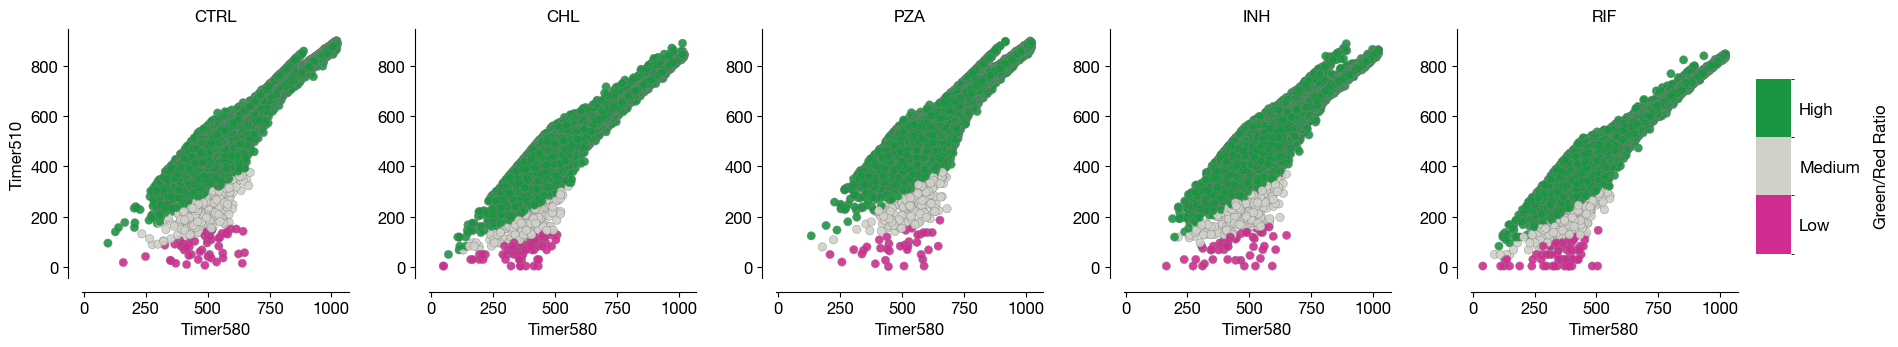

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. Ubuntu/Scientific Setup
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12

# 2. Filter Data First (so we calculate bounds on the correct data)
compound_order = ["CTRL", "CHL", "PZA", "INH", "RIF"]
upper_bound = in_vitro_df['Ratio'].quantile(0.99)
subset_df = in_vitro_df[in_vitro_df['Ratio'] <= upper_bound]

# 3. Define Bounds based on the CURRENT data (subset_df)
vmin = subset_df["Ratio"].min()
vmax = subset_df["Ratio"].max()
r = vmax - vmin

# Asymmetric Bins: 25% (Mag), 25% (Grey), 50% (Green)
bounds = [vmin, vmin + 0.25 * r, vmin + 0.5 * r, vmax]

# Define Colors: Magenta (Low), Grey (Mid), Green (High)
colors = ['#d02c91', '#d1d1ca', '#1a9641']
cmap_3tone = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap_3tone.N)

# 4. Plotting
g = sns.relplot(
    data=subset_df,
    x='582_15-Yellow-A',
    y='530_30-Blue-A',
    col='Compound',
    col_order=compound_order,
    col_wrap=5,
    hue='Ratio',
    palette=cmap_3tone,
    hue_norm=norm,
    edgecolor='grey',
    linewidth=0.3,
    legend=False,
    kind='scatter',
    height=3.5,
    aspect=1,
    alpha=0.9
)

g.set_axis_labels("Timer580", "Timer510")
g.set_titles('{col_name}')
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)

for ax in g.axes.flat:
    sns.despine(ax=ax, offset=10)

# 5. Custom Colorbar (No Ticks)
sm = plt.cm.ScalarMappable(cmap=cmap_3tone, norm=norm)
sm.set_array([])

cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])

# Calculate positions for labels relative to the new range
ticks = [
    vmin + 0.125 * r,
    vmin + 0.375 * r,
    vmin + 0.75 * r
]

cbar = g.figure.colorbar(sm, cax=cbar_ax, ticks=ticks)
cbar.set_label("Green/Red Ratio", labelpad=10)
cbar.ax.set_yticklabels(['Low', 'Medium', 'High'])
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0, pad=6)
output_path = '/Volumes/OPERA3/Nathan/data/macrohet/incellulo_timer_flow/in_vitro_FS7E.png'

plt.savefig(f'{output_path}', dpi=314, bbox_inches='tight')
plt.show()

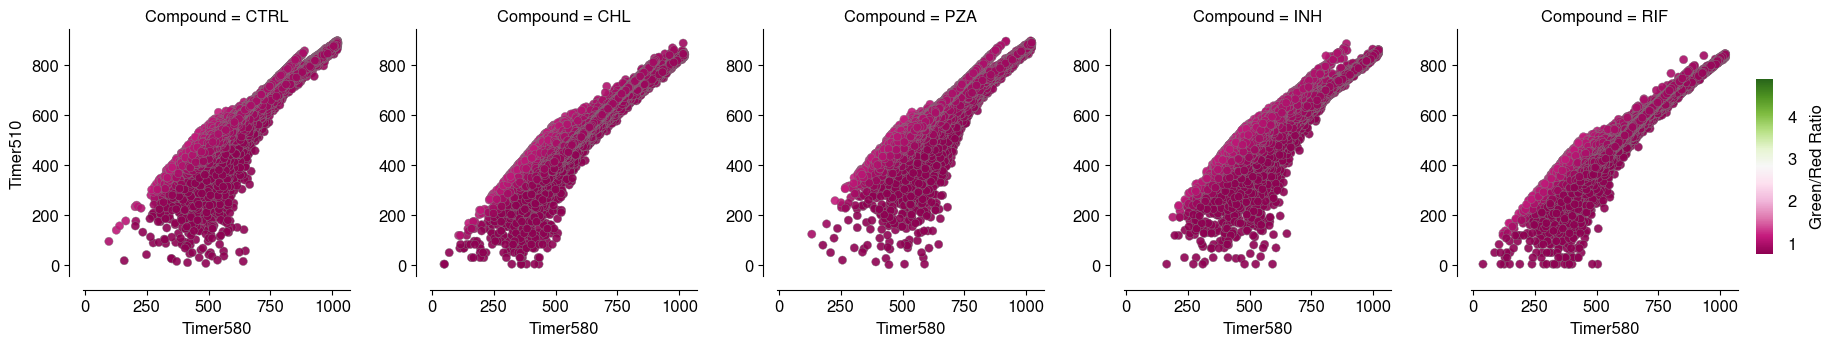

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.size'] = 12 # Set global font size to 9

# Define compounds and colors
compound_order = ["CTRL", "CHL", "PZA", "INH", "RIF"]
pal = sns.color_palette("PiYG", 5)[::-1]  # Reversed PiYG color palette
compound_colors = dict(zip(compound_order, pal))

# Subset the DataFrame
upper_bound = in_vitro_df['Ratio'].quantile(0.99)
subset_df = in_vitro_df[in_vitro_df['Ratio'] <= upper_bound]

# Define the range for the hue based on in_cellulo_df
hue_min = in_cellulo_df['Ratio'].min()
hue_max = in_cellulo_df['Ratio'].max()

# Create the scatter plot
g = sns.relplot(
    data=subset_df,
    x='582_15-Yellow-A',  # X-axis: Yellow (magenta)
    y='530_30-Blue-A',    # Y-axis: Blue (green)
    hue='Ratio',          # Color points by Ratio
    hue_norm=(hue_min, hue_max),  # Set hue range to match in_cellulo_df
    col='Compound',       # Separate into columns by Compound
    col_order=compound_order,  # Order of compounds
    col_wrap=5,           # Wrap columns after 5 plots
    palette='PiYG',       # Color palette for Ratio
    facet_kws={'sharex': True, 'sharey': True},  # Share axes across subplots
    edgecolor='grey',     # Add grey edge color to points
    linewidth=0.3,        # Adjust edge linewidth
    legend=False,         # Disable legend
    kind='scatter',       # Specify scatter plot
    height=3.5,           # Height of each subplot
    aspect=1,             # Aspect ratio of each subplot
    alpha=0.9,            # Transparency of points
)

# Customize the plot
g.set_axis_labels("Timer580", "Timer510")  # Updated axis labels
g.set_titles('Compound = {col_name}')  # Use Compound names as titles
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust subplot spacing
# g.fig.suptitle('Scatter Plot: 530_30-Blue-A vs 582_15-Yellow-A by Compound (Colored by Ratio)', y=1.02)

# Add despine with offset
for ax in g.axes.flat:
    sns.despine(ax=ax, offset=10)  # Add offset despine of 10

# # Add a colorbar for the Ratio (matching PiYG color scheme)
# norm = mpl.colors.Normalize(vmin=0, vmax=1)  # Normalize colorbar to [0, 1]
# sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
# sm.set_array([])

# # Create a colorbar axis
# cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])  # Position of the colorbar
# cbar = g.figure.colorbar(sm, cax=cbar_ax)
# cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)  # Colorbar label
# cbar.outline.set_visible(False)  # Remove colorbar outline
# cbar.ax.tick_params(length=4, width=0., pad=6)  # Customize colorbar ticks

# Add a colorbar manually **without squashing** USING SAME AS PREVIOUS IN CELLULO
norm = mpl.colors.Normalize(vmin=in_cellulo_df["Ratio"].min(), vmax=in_cellulo_df["Ratio"].max())
sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
sm.set_array([])  # Dummy array for colorbar

# Create a new axis for the colorbar outside the plot
cbar_ax = g.figure.add_axes([1, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
cbar = g.figure.colorbar(sm, cax=cbar_ax)
cbar.set_label("Green/Red Ratio", labelpad=10)
# **Remove colorbar outline (spines)**
cbar.outline.set_visible(False)

# **Increase padding of tick labels**
cbar.ax.tick_params(length=4, width=0., pad=6)  # Adjust tick length, width, and padding

# Save the plot
plt.savefig(f'{save_dir}/scatterplot_incellulo_cbar.pdf', dpi=314, bbox_inches='tight')

plt.show()

In [105]:
in_vitro_df[in_vitro_df['Compound'] == 'RIF']['530_30-Blue-A'].describe()

count    74211.000000
mean       533.696191
std         96.744331
min          4.000000
25%        473.000000
50%        534.000000
75%        593.000000
max        847.000000
Name: 530_30-Blue-A, dtype: float64

In [111]:
matching_rows = in_cellulo_df[in_cellulo_df['530_30-Blue-A'] == in_cellulo_df['582_15-Yellow-A']]
print(matching_rows)


       FSC-A  FSC-H  SSC-A  SSC-H  530_30-Blue-A  582_15-Yellow-A  Time  \
155       39     28     42     45            500              500     9   
166       36     32     44     51            450              450    10   
259       48     29     64     50            579              579    17   
524      421    236    539    410            563              563    34   
532       48     45     55     48            577              577    34   
...      ...    ...    ...    ...            ...              ...   ...   
33415     40     34     37     38            509              509   975   
33555     53     43     57     53            509              509   986   
33630     45     38     31     18            458              458   992   
33908    525    214    759    378            593              593  1017   
33942    324    256    461    398            542              542  1020   

      Compound  Ratio     Dataset  
155        INH    1.0  In Cellulo  
166        INH    1.0  In C

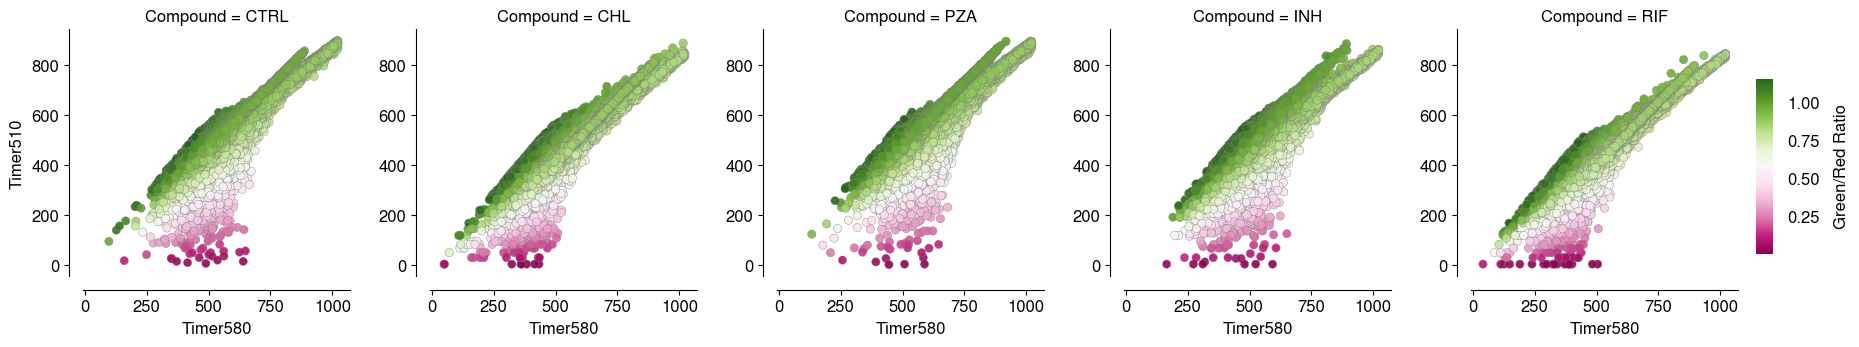

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.size'] = 12 # Set global font size to 9

# Define compounds and colors
compound_order = ["CTRL", "CHL", "PZA", "INH", "RIF"]
pal = sns.color_palette("PiYG", 5)[::-1]  # Reversed PiYG color palette
compound_colors = dict(zip(compound_order, pal))

# Subset the DataFrame
upper_bound = in_vitro_df['Ratio'].quantile(0.99)
subset_df = in_vitro_df[in_vitro_df['Ratio'] <= upper_bound]

# # Define quantiles for filtering
# lower_quantile = 0.01  # Lower bound (1st percentile)
# upper_quantile = 0.99  # Upper bound (99th percentile)

# # Calculate bounds for Ratio, 530_30-Blue-A, and 582_15-Yellow-A
# ratio_lower_bound = in_vitro_df['Ratio'].quantile(lower_quantile)
# ratio_upper_bound = in_vitro_df['Ratio'].quantile(upper_quantile)

# blue_lower_bound = in_vitro_df['530_30-Blue-A'].quantile(lower_quantile)
# blue_upper_bound = in_vitro_df['530_30-Blue-A'].quantile(upper_quantile)

# yellow_lower_bound = in_vitro_df['582_15-Yellow-A'].quantile(lower_quantile)
# yellow_upper_bound = in_vitro_df['582_15-Yellow-A'].quantile(upper_quantile)

# # Filter the DataFrame based on the bounds
# subset_df = in_vitro_df[
#     (in_vitro_df['Ratio'] >= ratio_lower_bound) &
#     (in_vitro_df['Ratio'] <= ratio_upper_bound) &
#     (in_vitro_df['530_30-Blue-A'] >= blue_lower_bound) &
#     (in_vitro_df['530_30-Blue-A'] <= blue_upper_bound) &
#     (in_vitro_df['582_15-Yellow-A'] >= yellow_lower_bound) &
#     (in_vitro_df['582_15-Yellow-A'] <= yellow_upper_bound)
# ]


# Create the scatter plot
g = sns.relplot(
    data=subset_df,
    x='582_15-Yellow-A',  # X-axis: Yellow (magenta)
    y='530_30-Blue-A',    # Y-axis: Blue (green)
    hue='Ratio',          # Color points by Ratio
    col='Compound',       # Separate into columns by Compound
    col_order=compound_order,  # Order of compounds
    col_wrap=5,           # Wrap columns after 5 plots
    palette='PiYG',       # Color palette for Ratio
    facet_kws={'sharex': True, 'sharey': True},  # Share axes across subplots
    edgecolor='grey',     # Add grey edge color to points
    linewidth=0.3,        # Adjust edge linewidth
    legend=False,         # Disable legend
    kind='scatter',       # Specify scatter plot
    height=3.5,           # Height of each subplot
    aspect=1,             # Aspect ratio of each subplot
    alpha=0.9,            # Transparency of points
)

# Customize the plot
g.set_axis_labels("Timer580", "Timer510")  # Updated axis labels
g.set_titles('Compound = {col_name}')  # Use Compound names as titles
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust subplot spacing
# g.fig.suptitle('Scatter Plot: 530_30-Blue-A vs 582_15-Yellow-A by Compound (Colored by Ratio)', y=1.02)

# Add despine with offset
for ax in g.axes.flat:
    sns.despine(ax=ax, offset=10)  # Add offset despine of 10

# # Add a colorbar for the Ratio (matching PiYG color scheme)
# norm = mpl.colors.Normalize(vmin=0, vmax=1)  # Normalize colorbar to [0, 1]
# sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
# sm.set_array([])

# # Create a colorbar axis
# cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])  # Position of the colorbar
# cbar = g.figure.colorbar(sm, cax=cbar_ax)
# cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)  # Colorbar label
# cbar.outline.set_visible(False)  # Remove colorbar outline
# cbar.ax.tick_params(length=4, width=0., pad=6)  # Customize colorbar ticks

# Add a colorbar manually **without squashing** USING SAME AS PREVIOUS IN CELLULO
norm = mpl.colors.Normalize(vmin=subset_df["Ratio"].min(), vmax=subset_df["Ratio"].max())
sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
sm.set_array([])  # Dummy array for colorbar

# Create a new axis for the colorbar outside the plot
cbar_ax = g.figure.add_axes([1, 0.25, 0.01, 0.5])  # [left, bottom, width, height]
cbar = g.figure.colorbar(sm, cax=cbar_ax)
cbar.set_label("Green/Red Ratio", labelpad=10)
# **Remove colorbar outline (spines)**
cbar.outline.set_visible(False)

# **Increase padding of tick labels**
cbar.ax.tick_params(length=4, width=0., pad=6)  # Adjust tick length, width, and padding

# Save the plot
plt.savefig(f'{save_dir}/scatterplot_invitro_cbar.pdf', dpi=314, bbox_inches='tight')

plt.show()

/tmp/ipykernel_126835/2606509114.py:10: UserWarning: 
The palette list has fewer values (5) than needed (51066) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


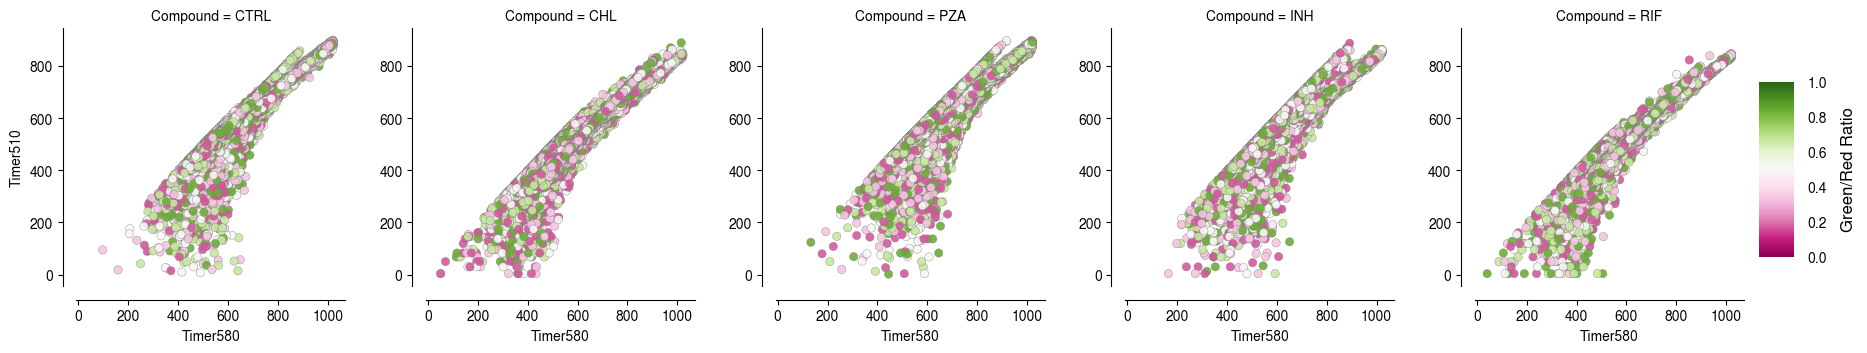

In [75]:
# Define compounds and colors
compound_order = ["CTRL", "CHL", "PZA", "INH", "RIF"]
pal = sns.color_palette("PiYG", 5)[::-1]  # Reversed PiYG color palette
compound_colors = dict(zip(compound_order, pal))

subset_df = in_vitro_df[in_vitro_df['Ratio'] < 1]


### **Scatterplot**
g = sns.relplot(
    data=subset_df, 
    x='582_15-Yellow-A', 
    y='530_30-Blue-A', 
    palette=pal,  
    col='Compound',
    col_order=compound_order,  
    col_wrap=5,  
    alpha=0.9,
    hue='Ratio',
    edgecolor='grey',
    linewidth=0.3,
    legend=False,
    kind='scatter',
    height=3.5,
    aspect=1,
)

g.set_axis_labels("Timer580", "Timer510")
g.figure.subplots_adjust(wspace=0.3, hspace=0.3)
sns.despine(offset=10)

# Add a colorbar
# norm = mpl.colors.Normalize(vmin=in_vitro_df["Ratio"].min(), vmax=in_vitro_df["Ratio"].max())
norm = mpl.colors.Normalize(vmin=0, vmax=1)

sm = plt.cm.ScalarMappable(cmap="PiYG", norm=norm)
sm.set_array([])

cbar_ax = g.figure.add_axes([1, 0.25, 0.02, 0.5])
cbar = g.figure.colorbar(sm, cax=cbar_ax)
cbar.set_label("Green/Red Ratio", fontsize=12, labelpad=10)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=4, width=0., pad=6)

plt.savefig(f'{save_dir}/scatterplot.pdf', dpi=314, bbox_inches='tight')
plt.show()


/tmp/ipykernel_126835/3552904439.py:2: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  g = sns.displot(data=in_vitro_df,


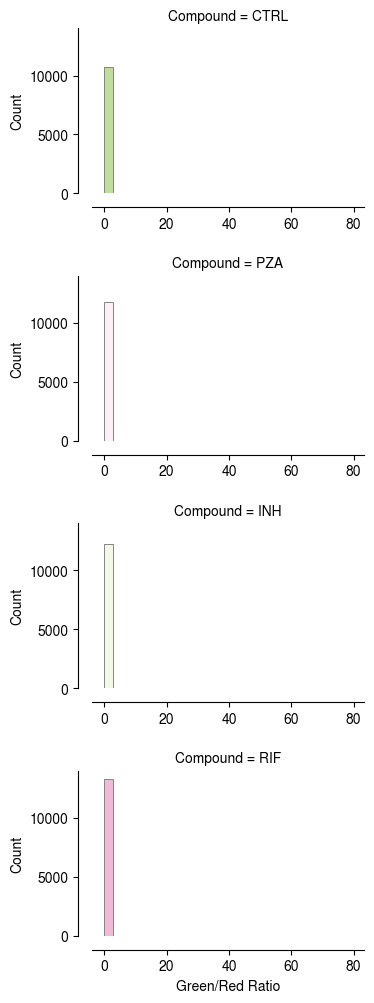

In [13]:
### **Histogram**
g = sns.displot(data=in_vitro_df, 
                x='Ratio', 
                col='Compound', 
                col_order=compound_order,  
                col_wrap=1,
                bins=30,  
                kde=False,
                facet_kws={'sharex': True, 'sharey': True},  
                aspect=1.5, 
                height=2.5,  
                hue='Compound',
                palette=pal, 
                edgecolor='gray'
               )

g.set_axis_labels("Green/Red Ratio", "Count")
g.figure.subplots_adjust(hspace=0.5)

# g.set(xlim=(0.4, 1.4))

if g._legend:  
    g._legend.remove()

sns.despine(offset=10)

plt.savefig(f'{save_dir}/histogram_1col.pdf', dpi=314, bbox_inches='tight')
plt.show()


In [ ]:

### **KDE Plot**
in_vitro_df["Compound"] = pd.Categorical(in_vitro_df["Compound"], categories=compound_order, ordered=True)

g = sns.FacetGrid(in_vitro_df, row="Compound", hue="Compound", aspect=3, height=1, palette=pal)

g.map(sns.kdeplot, "Ratio",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)

g.map(sns.kdeplot, "Ratio", clip_on=False, color="w", lw=2, bw_adjust=.5)

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    text = ax.text(0, .1, label, fontweight="bold", color=color,
                   ha="left", va="center", transform=ax.transAxes,
                   fontsize=16)
    text.set_path_effects([path_effects.Stroke(linewidth=1, foreground="gray"),
                           path_effects.Normal()])

g.map(label, "Ratio")

g.figure.subplots_adjust(hspace=-.65)
g.set_titles("")
g.set(yticks=[], ylabel="",)# xlim=(0.6,1.2))
g.despine(bottom=True, left=True)
g.set_axis_labels("Green:Red Ratio", "")

plt.figtext(0.6, -0.01, "KDE Distributions", fontsize=12, fontweight="heavy", ha="center")

plt.savefig(f'{save_dir}/kde_plot.pdf', dpi=314, bbox_inches='tight')